In [158]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [159]:
PROCESSED_DATA_DIR = Path("../data/processed")

In [160]:
training_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "training_actions.csv", sep=",", encoding="utf-8", parse_dates=["start_date", "end_date"])


info_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "info_actions.csv", sep=",", encoding="utf-8")

In [161]:
actions_analysis_df = training_actions_df.merge(
    info_actions_df, how="inner", on="course_id", validate="many_to_one"
)

actions_analysis_df = actions_analysis_df.loc[actions_analysis_df["active"]].drop_duplicates(subset=["action_id", "local", "status"])

actions_analysis_df

,action_id,course_id,local,start_date,end_date,modality,status,total_students,course_name,course_area,total_hours,active
0,P_HCP_0001,HCP,Centro 1,2018-01-01,2018-01-02,In-person,Finalizada,11,HACCP Aplicado,Alimentar,12,True
1,P_INF_0001,INF,Centro 1,2018-01-01,2018-01-03,In-person,Finalizada,11,"Infeção, Prevenção e Controlo",Saúde,16,True
2,P_PRI_0001,PRI,Centro 1,2018-01-01,2018-01-03,In-person,Finalizada,15,Primeiros Socorros,Saúde e Segurança,12,True
3,H_TUR_0004,TUR,Centro 5,2018-01-01,2018-01-05,Hybrid,Finalizada,20,Atendimento Turístico,Turismo,16,True
4,H_INF_0005,INF,Centro 5,2018-01-01,2018-01-06,Hybrid,Finalizada,20,"Infeção, Prevenção e Controlo",Saúde,16,True
...,...,...,...,...,...,...,...,...,...,...,...,...
19120,P_HAC_0778,HAC,Centro 4,2026-12-30,2026-12-31,In-person,Prevista,25,Higiene e Segurança Alimentar,Alimentar,8,True
19121,H_ING_0583,ING,Centro 2,2026-12-30,2026-12-31,Hybrid,Prevista,21,Inglês Profissional,Línguas,30,True
19122,E_PRO_0618,PRO,Centro 4,2026-12-30,2026-12-31,Online,Prevista,31,Gestão de Projetos,Gestão,25,True
19123,P_SCI_0684,SCI,Centro 3,2026-12-30,2026-12-31,In-person,Prevista,21,Segurança Contra Incêndios,Segurança,8,True


In [162]:
total_actions = actions_analysis_df["action_id"].nunique()
total_status = actions_analysis_df["status"].nunique()
total_modalities = actions_analysis_df["modality"].nunique()
total_time = (
    actions_analysis_df["end_date"].max() - actions_analysis_df["start_date"].min()
).days / 365

print(
    f"""
Total Actions: {total_actions}
Number of Status: {total_status}
Number of Modalities: {total_modalities}
Period of Time: {total_time:.0f} years
""".strip()
)

Total Actions: 19125
Number of Status: 4
Number of Modalities: 3
Period of Time: 9 years


In [163]:
def summarize_actions(df, group_columns):
    summary = (
        df
        .groupby(group_columns, as_index=False)
        .agg(
            actions_count=("action_id", "nunique"),
            students_count=("total_students", "sum")
        )
        .assign(
            pct_actions=lambda data:
                data["actions_count"]
                .div(data["actions_count"].sum())
                .mul(100)
                .round(1),

            pct_students=lambda data:
                data["students_count"]
                .div(data["students_count"].sum())
                .mul(100)
                .round(1)
        )
        .sort_values(
            by="actions_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return summary

In [164]:
actions_course_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name"]
)

actions_course_count

,course_id,course_name,actions_count,students_count,pct_actions,pct_students
0,CYB,Cibersegurança Básica,1214,25214,6.3,7.0
1,PBI,Power BI e Visualização de Dados,1209,25308,6.3,7.0
2,SEG,Segurança no Trabalho,1069,20473,5.6,5.7
3,EXC,Excel Aplicado à Gestão,1024,21029,5.4,5.8
4,SST,Saúde e Segurança no Trabalho,1012,19273,5.3,5.3
5,PRI,Primeiros Socorros,953,16724,5.0,4.6
6,GER,Geriatria e Apoio ao Idoso,937,16200,4.9,4.5
7,LOG,Logística e Gestão de Armazém,909,16084,4.8,4.4
8,MNT,Manutenção Industrial Básica,851,14091,4.4,3.9
9,PYT,Introdução à Programação em Python,789,16572,4.1,4.6


In [165]:
actions_local_count = summarize_actions(
    actions_analysis_df,
    ["local"]
)

actions_local_count

,local,actions_count,students_count,pct_actions,pct_students
0,Centro 2,4090,78532,21.4,21.7
1,Centro 4,3845,73373,20.1,20.3
2,Centro 1,3818,71843,20.0,19.8
3,Centro 5,3741,69936,19.6,19.3
4,Centro 3,3631,68253,19.0,18.9


In [166]:
actions_status_count = summarize_actions(
    actions_analysis_df,
    ["status"]
)

actions_status_count

,status,actions_count,students_count,pct_actions,pct_students
0,Finalizada,16619,323260,86.9,89.3
1,Prevista,1582,34344,8.3,9.5
2,Cancelada,866,3035,4.5,0.8
3,Em andamento,58,1298,0.3,0.4


In [167]:
actions_modalities_count = summarize_actions(
    actions_analysis_df,
    ["modality"]
)

actions_modalities_count

,modality,actions_count,students_count,pct_actions,pct_students
0,In-person,9357,154288,48.9,42.6
1,Hybrid,6188,120835,32.4,33.4
2,Online,3580,86814,18.7,24.0


In [168]:
actions_area_count = summarize_actions(
    actions_analysis_df,
    ["course_area"]
)

actions_area_count

,course_area,actions_count,students_count,pct_actions,pct_students
0,Informática,4236,88123,22.1,24.3
1,Segurança,3372,62005,17.6,17.1
2,Gestão,1999,39791,10.5,11.0
3,Saúde,1627,28153,8.5,7.8
4,Alimentar,1480,26839,7.7,7.4
5,Saúde e Segurança,1433,25091,7.5,6.9
6,Turismo,1195,20827,6.2,5.8
7,Logística,909,16084,4.8,4.4
8,Manutenção,851,14091,4.4,3.9
9,Comercial,754,14901,3.9,4.1


In [169]:
actions_course_local_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "local"]
)

actions_course_local_count

,course_id,course_name,local,actions_count,students_count,pct_actions,pct_students
0,PBI,Power BI e Visualização de Dados,Centro 4,324,6768,1.7,1.9
1,CYB,Cibersegurança Básica,Centro 4,320,6615,1.7,1.8
2,PBI,Power BI e Visualização de Dados,Centro 2,319,6718,1.7,1.9
3,CYB,Cibersegurança Básica,Centro 2,307,6190,1.6,1.7
4,SEG,Segurança no Trabalho,Centro 5,268,5103,1.4,1.4
...,...,...,...,...,...,...,...
115,HOT,Housekeeping e Operações Hoteleiras,Centro 4,85,1440,0.4,0.4
116,SOC,Socorrismo Básico,Centro 2,84,1470,0.4,0.4
117,TUR,Atendimento Turístico,Centro 3,83,1354,0.4,0.4
118,SOC,Socorrismo Básico,Centro 1,67,1215,0.4,0.3


In [170]:
actions_course_modality_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "modality"]
)

actions_course_modality_count.head(25)

,course_id,course_name,modality,actions_count,students_count,pct_actions,pct_students
0,MNT,Manutenção Industrial Básica,In-person,851,14091,4.4,3.9
1,PRI,Primeiros Socorros,In-person,640,10623,3.3,2.9
2,GER,Geriatria e Apoio ao Idoso,In-person,615,10135,3.2,2.8
3,EMP,Empilhadores e Movimentação de Cargas,In-person,606,10046,3.2,2.8
4,LOG,Logística e Gestão de Armazém,In-person,590,9821,3.1,2.7
5,SEG,Segurança no Trabalho,In-person,541,9068,2.8,2.5
6,PBI,Power BI e Visualização de Dados,Online,517,12423,2.7,3.4
7,SST,Saúde e Segurança no Trabalho,In-person,507,8405,2.7,2.3
8,CYB,Cibersegurança Básica,Online,486,11692,2.5,3.2
9,HCP,HACCP Aplicado,In-person,474,7701,2.5,2.1


In [171]:
actions_course_status_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "status"]
)

actions_course_status_count.head(25)

,course_id,course_name,status,actions_count,students_count,pct_actions,pct_students
0,CYB,Cibersegurança Básica,Finalizada,1031,22056,5.4,6.1
1,PBI,Power BI e Visualização de Dados,Finalizada,1023,22061,5.3,6.1
2,SEG,Segurança no Trabalho,Finalizada,955,18705,5.0,5.2
3,SST,Saúde e Segurança no Trabalho,Finalizada,890,17333,4.7,4.8
4,EXC,Excel Aplicado à Gestão,Finalizada,874,18813,4.6,5.2
5,PRI,Primeiros Socorros,Finalizada,834,15025,4.4,4.2
6,LOG,Logística e Gestão de Armazém,Finalizada,800,14464,4.2,4.0
7,GER,Geriatria e Apoio ao Idoso,Finalizada,797,14231,4.2,3.9
8,MNT,Manutenção Industrial Básica,Finalizada,728,12363,3.8,3.4
9,HAC,Higiene e Segurança Alimentar,Finalizada,686,13384,3.6,3.7


In [172]:
actions_local_modalities_count = summarize_actions(
    actions_analysis_df,
    ["local", "modality"]
)

actions_local_modalities_count

,local,modality,actions_count,students_count,pct_actions,pct_students
0,Centro 5,In-person,1947,32229,10.2,8.9
1,Centro 1,In-person,1901,31051,9.9,8.6
2,Centro 3,In-person,1869,30910,9.8,8.5
3,Centro 2,In-person,1864,30932,9.7,8.5
4,Centro 4,In-person,1776,29166,9.3,8.1
5,Centro 2,Hybrid,1357,26411,7.1,7.3
6,Centro 1,Hybrid,1244,24464,6.5,6.8
7,Centro 4,Hybrid,1241,24277,6.5,6.7
8,Centro 5,Hybrid,1174,22733,6.1,6.3
9,Centro 3,Hybrid,1172,22950,6.1,6.3


In [173]:
actions_local_status_count = summarize_actions(
    actions_analysis_df,
    ["local", "status"]
)

actions_local_status_count

,local,status,actions_count,students_count,pct_actions,pct_students
0,Centro 2,Finalizada,3536,69961,18.5,19.3
1,Centro 4,Finalizada,3345,65690,17.5,18.1
2,Centro 1,Finalizada,3336,64402,17.4,17.8
3,Centro 5,Finalizada,3245,62297,17.0,17.2
4,Centro 3,Finalizada,3157,60910,16.5,16.8
5,Centro 2,Prevista,358,7683,1.9,2.1
6,Centro 5,Prevista,313,6747,1.6,1.9
7,Centro 1,Prevista,306,6733,1.6,1.9
8,Centro 4,Prevista,305,6650,1.6,1.8
9,Centro 3,Prevista,300,6531,1.6,1.8


In [174]:
actions_modality_status_count = summarize_actions(
    actions_analysis_df,
    ["modality", "status"]
)

actions_modality_status_count

,modality,status,actions_count,students_count,pct_actions,pct_students
0,In-person,Finalizada,8150,138171,42.6,38.2
1,Hybrid,Finalizada,5384,107813,28.2,29.8
2,Online,Finalizada,3085,77276,16.1,21.4
3,In-person,Prevista,751,14365,3.9,4.0
4,Hybrid,Prevista,523,11633,2.7,3.2
5,In-person,Cancelada,445,1559,2.3,0.4
6,Online,Prevista,308,8346,1.6,2.3
7,Hybrid,Cancelada,259,921,1.4,0.3
8,Online,Cancelada,162,555,0.8,0.2
9,Online,Em andamento,25,637,0.1,0.2


In [175]:
all_actions_count = summarize_actions(
    actions_analysis_df,
    ["course_id", "course_name", "local", "modality", "status"]
)

all_actions_count

,course_id,course_name,local,modality,status,actions_count,students_count,pct_actions,pct_students
0,MNT,Manutenção Industrial Básica,Centro 1,In-person,Finalizada,192,3155,1.0,0.9
1,MNT,Manutenção Industrial Básica,Centro 5,In-person,Finalizada,171,2921,0.9,0.8
2,GER,Geriatria e Apoio ao Idoso,Centro 3,In-person,Finalizada,157,2710,0.8,0.7
3,PRI,Primeiros Socorros,Centro 3,In-person,Finalizada,155,2685,0.8,0.7
4,MNT,Manutenção Industrial Básica,Centro 4,In-person,Finalizada,149,2558,0.8,0.7
...,...,...,...,...,...,...,...,...,...
879,GER,Geriatria e Apoio ao Idoso,Centro 4,Hybrid,Em andamento,1,24,0.0,0.0
880,SST,Saúde e Segurança no Trabalho,Centro 1,Online,Cancelada,1,7,0.0,0.0
881,PYT,Introdução à Programação em Python,Centro 5,In-person,Em andamento,1,15,0.0,0.0
882,PYT,Introdução à Programação em Python,Centro 5,Online,Cancelada,1,5,0.0,0.0


In [176]:
all_actions_count[["actions_count", "students_count"]].describe().round(2)

,actions_count,students_count
count,884.00,884.00
mean,21.63,409.43
std,29.98,579.17
min,1.00,0.00
25%,3.00,18.00
50%,6.00,103.00
75%,35.00,717.00
max,192.00,3155.00


In [177]:
def plot_actions_overview(charts, title, ylabel="Number of Actions", nrows=2, ncols=2, figsize=(13, 9)):

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(title, fontsize=16, fontweight="bold")

    for ax, chart in zip(axes.flat, charts.values()):

        plot_df = chart["df"].copy()

        if "top_n" in chart:
            plot_df = plot_df.head(chart["top_n"])

        categories = plot_df[chart["label_column"]].astype(str)
        values = plot_df["actions_count"]
        percentages = plot_df["pct_actions"]

        bars = ax.bar(categories, values)

        labels = [
            f"{value}\n({percentage:.1f}%)"
            for value, percentage in zip(values, percentages)
        ]

        ax.bar_label(bars, labels=labels, padding=4, fontsize=8)

        ax.set_title(chart["title"], loc="left", fontweight="bold", pad=25)

        ax.text(
            0,
            1.02,
            chart["description"],
            transform=ax.transAxes,
            fontsize=9,
            color="#6B7280"
        )

        ax.set_facecolor("#FFFFFF")
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, values.max() * 1.25)

        ax.tick_params(axis="x", rotation=45)

        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")

    plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=3)

    plt.show()

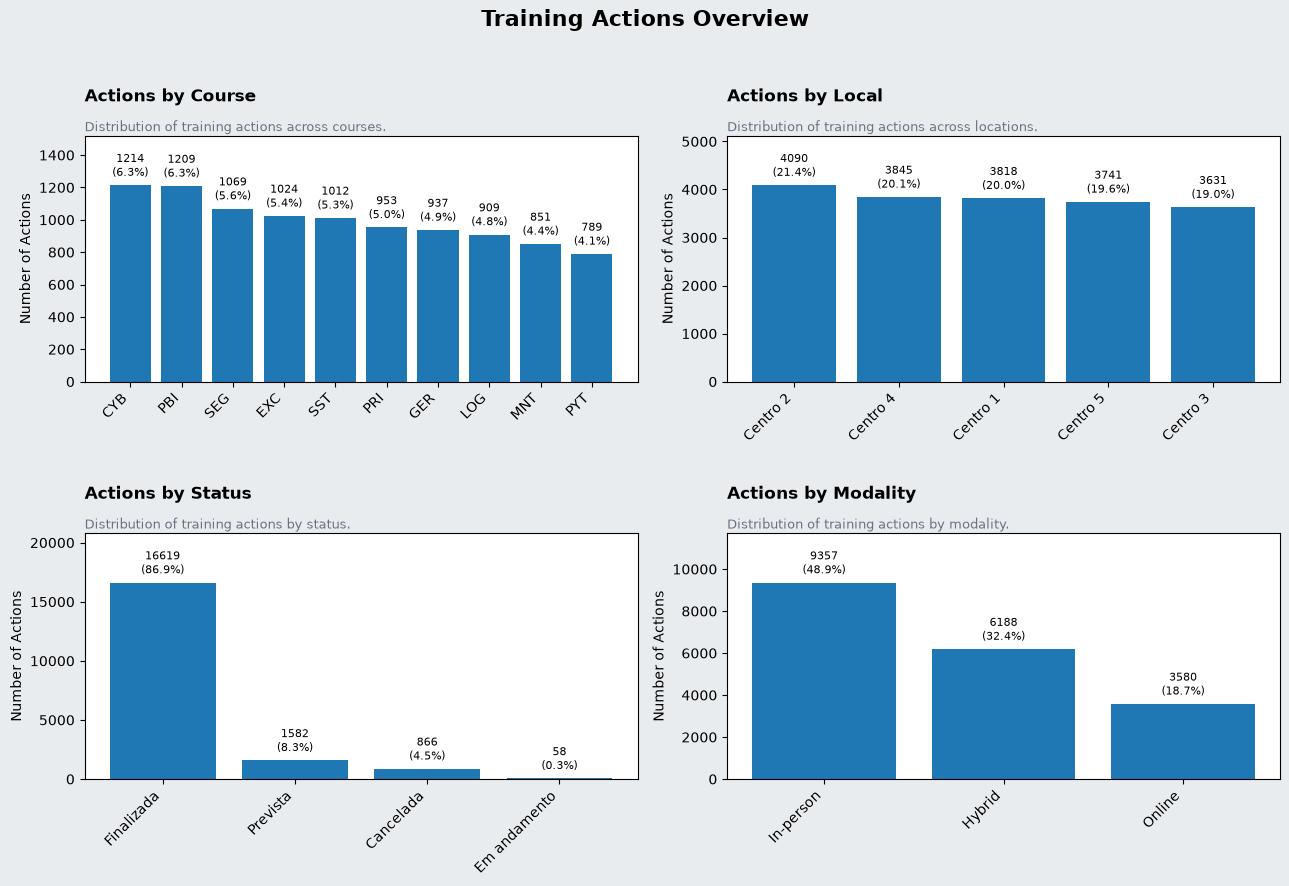

In [178]:
actions_overview_charts = {
    "courses": {
        "df": actions_course_count,
        "label_column": "course_id",
        "title": "Actions by Course",
        "description": "Distribution of training actions across courses.",
        "top_n": 10
    },

    "locals": {
        "df": actions_local_count,
        "label_column": "local",
        "title": "Actions by Local",
        "description": "Distribution of training actions across locations."
    },

    "status": {
        "df": actions_status_count,
        "label_column": "status",
        "title": "Actions by Status",
        "description": "Distribution of training actions by status."
    },

    "modalities": {
        "df": actions_modalities_count,
        "label_column": "modality",
        "title": "Actions by Modality",
        "description": "Distribution of training actions by modality."
    }
}

plot_actions_overview(
    charts=actions_overview_charts,
    title="Training Actions Overview"
)

In [179]:
group_columns = [
    "course_id",
    "course_name",
    "course_area",
    "local"
]


actions_features_base = (
    actions_analysis_df
    .loc[
        actions_analysis_df["status"].ne("Cancelada"),
        group_columns + [
            "action_id",
            "start_date",
            "end_date",
            "total_hours"
        ]
    ]
    .copy()
)

actions_features_base["end_date"] = (
    actions_features_base["end_date"]
    .fillna(actions_features_base["start_date"])
)

actions_features_base["action_month"] = (
    actions_features_base["start_date"]
    .dt.to_period("M")
)

reference_month = (
    actions_features_base["action_month"]
    .max()
)

last_12m_start_month = reference_month - 11

reference_date = (
    reference_month
    .end_time
    .normalize()
)

actions_features_base = (
    actions_features_base
    .loc[
        actions_features_base["start_date"]
        .le(reference_date)
    ]
    .copy()
)


actions_features_base["period"] = "historical"

actions_features_base.loc[
    actions_features_base["action_month"]
    .ge(last_12m_start_month),
    "period"
] = "last_12m"


course_local_combinations = (
    actions_features_base[group_columns]
    .drop_duplicates()
    .reset_index(drop=True)
)


print(
    f"Últimos 12 meses: "
    f"{last_12m_start_month} até {reference_month}"
)

print(
    f"Histórico: até {last_12m_start_month - 1}"
)

Últimos 12 meses: 2026-01 até 2026-12
Histórico: até 2025-12


In [180]:
all_months_df = pd.DataFrame({
    "action_month": pd.period_range(
        start=actions_features_base["action_month"].min(),
        end=reference_month,
        freq="M"
    )
})


monthly_actions_count_df = (
    actions_features_base
    .groupby(
        group_columns + ["action_month"],
        as_index=False
    )
    .agg(
        actions_count=(
            "action_id",
            "nunique"
        ),

        training_hours=(
            "total_hours",
            "sum"
        )
    )
)


actions_monthly_df = (
    course_local_combinations
    .merge(
        all_months_df,
        how="cross"
    )
    .merge(
        monthly_actions_count_df,
        on=group_columns + ["action_month"],
        how="left",
        validate="one_to_one"
    )
    .fillna({
        "actions_count": 0,
        "training_hours": 0
    })
)


actions_monthly_df["actions_count"] = (
    actions_monthly_df["actions_count"]
    .astype(int)
)


actions_monthly_df["period"] = "historical"

actions_monthly_df.loc[
    actions_monthly_df["action_month"]
    .ge(last_12m_start_month),
    "period"
] = "last_12m"


actions_monthly_df = (
    actions_monthly_df
    .sort_values(
        group_columns + ["action_month"]
    )
    .reset_index(drop=True)
)


actions_monthly_df["active_month"] = (
    actions_monthly_df["actions_count"]
    .gt(0)
    .astype(int)
)


actions_monthly_df["actions_monthly_change"] = (
    actions_monthly_df
    .groupby(group_columns)["actions_count"]
    .diff()
)


actions_monthly_df.head()

,course_id,course_name,course_area,local,action_month,actions_count,training_hours,period,active_month,actions_monthly_change
0,CYB,Cibersegurança Básica,Informática,Centro 1,2018-01,1,16.0,historical,1,NaN
1,CYB,Cibersegurança Básica,Informática,Centro 1,2018-02,0,0.0,historical,0,-1.0
2,CYB,Cibersegurança Básica,Informática,Centro 1,2018-03,0,0.0,historical,0,0.0
3,CYB,Cibersegurança Básica,Informática,Centro 1,2018-04,0,0.0,historical,0,0.0
4,CYB,Cibersegurança Básica,Informática,Centro 1,2018-05,1,16.0,historical,1,1.0


In [181]:
volume_last_12m_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        actions_monthly_avg_last_12m=(
            "actions_count",
            "mean"
        ),

        training_hours_monthly_avg_last_12m=(
            "training_hours",
            "mean"
        )
    )
)


volume_historical_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        actions_monthly_avg_historical=(
            "actions_count",
            "mean"
        ),

        training_hours_monthly_avg_historical=(
            "training_hours",
            "mean"
        )
    )
)


actions_volume_features_df = (
    course_local_combinations
    .merge(
        volume_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        volume_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_volume_features_df

,course_id,course_name,course_area,local,actions_monthly_avg_last_12m,training_hours_monthly_avg_last_12m,actions_monthly_avg_historical,training_hours_monthly_avg_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,2.083333,25.000000,1.145833,13.750000
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,1.250000,20.000000,0.802083,12.833333
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,3.333333,40.000000,1.968750,23.625000
3,TUR,Atendimento Turístico,Turismo,Centro 5,2.416667,38.666667,1.041667,16.666667
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,1.750000,28.000000,0.875000,14.000000
...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,2.583333,41.333333,0.968750,15.500000
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,3.833333,61.333333,2.093750,33.500000
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,2.000000,50.000000,1.416667,35.416667
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,2.250000,36.000000,1.406250,22.500000


In [182]:
growth_last_12m_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        actions_monthly_change_avg_last_12m=(
            "actions_monthly_change",
            "mean"
        )
    )
)


growth_historical_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        actions_monthly_change_avg_historical=(
            "actions_monthly_change",
            "mean"
        )
    )
)


actions_growth_features_df = (
    course_local_combinations
    .merge(
        growth_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        growth_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_growth_features_df

,course_id,course_name,course_area,local,actions_monthly_change_avg_last_12m,actions_monthly_change_avg_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,0.083333,-0.010526
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,0.000000,-0.021053
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,-0.083333,0.000000
3,TUR,Atendimento Turístico,Turismo,Centro 5,0.000000,0.000000
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,-0.083333,0.000000
...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,0.000000,0.021053
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,-0.083333,0.021053
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,0.083333,0.000000
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,-0.083333,0.010526


In [183]:
action_dates_df = (
    actions_features_base[
        group_columns + [
            "start_date",
            "period"
        ]
    ]
    .drop_duplicates(
        subset=group_columns + ["start_date"]
    )
    .sort_values(
        group_columns + ["start_date"]
    )
    .reset_index(drop=True)
)


action_dates_df["days_between_actions"] = (
    action_dates_df
    .groupby(group_columns)["start_date"]
    .diff()
    .dt.days
)


recurrence_last_12m_df = (
    action_dates_df
    .loc[
        action_dates_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        median_days_between_actions_last_12m=(
            "days_between_actions",
            "median"
        )
    )
)


recurrence_historical_df = (
    action_dates_df
    .loc[
        action_dates_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        median_days_between_actions_historical=(
            "days_between_actions",
            "median"
        )
    )
)


actions_recurrence_features_df = (
    course_local_combinations
    .merge(
        recurrence_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        recurrence_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_recurrence_features_df

,course_id,course_name,course_area,local,median_days_between_actions_last_12m,median_days_between_actions_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,10.0,21.0
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,20.0,27.0
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,7.0,12.0
3,TUR,Atendimento Turístico,Turismo,Centro 5,10.0,22.0
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,16.5,21.0
...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,13.0,21.0
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,6.5,13.0
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,10.0,14.0
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,8.0,19.0


In [184]:
regularity_last_12m_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        active_month_ratio_last_12m=(
            "active_month",
            "mean"
        )
    )
)


regularity_historical_df = (
    actions_monthly_df
    .loc[
        actions_monthly_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        active_month_ratio_historical=(
            "active_month",
            "mean"
        )
    )
)


actions_regularity_features_df = (
    course_local_combinations
    .merge(
        regularity_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        regularity_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_regularity_features_df

,course_id,course_name,course_area,local,active_month_ratio_last_12m,active_month_ratio_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,0.833333,0.677083
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,0.833333,0.510417
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,1.000000,0.802083
3,TUR,Atendimento Turístico,Turismo,Centro 5,0.916667,0.645833
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,0.916667,0.572917
...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,0.916667,0.593750
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,0.916667,0.802083
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,0.833333,0.718750
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,0.750000,0.718750


In [185]:
simultaneity_daily_df = (
    actions_features_base[
        group_columns + [
            "action_id",
            "start_date",
            "end_date"
        ]
    ]
    .assign(
        action_date=lambda df:
            df.apply(
                lambda row:
                    pd.date_range(
                        start=row["start_date"],
                        end=row["end_date"],
                        freq="D"
                    ),
                axis=1
            )
    )
    .explode("action_date")
)


simultaneity_daily_df["action_date"] = (
    pd.to_datetime(
        simultaneity_daily_df["action_date"]
    )
)


# Mantém apenas os dias até ao final
# do mês de referência
simultaneity_daily_df = (
    simultaneity_daily_df
    .loc[
        simultaneity_daily_df["action_date"]
        .le(reference_date)
    ]
    .copy()
)


simultaneity_daily_df["action_month"] = (
    simultaneity_daily_df["action_date"]
    .dt.to_period("M")
)


simultaneity_daily_df["period"] = "historical"

simultaneity_daily_df.loc[
    simultaneity_daily_df["action_month"]
    .ge(last_12m_start_month),
    "period"
] = "last_12m"


simultaneity_daily_df = (
    simultaneity_daily_df
    .groupby(
        group_columns + [
            "period",
            "action_date"
        ],
        as_index=False
    )
    .agg(
        concurrent_actions=(
            "action_id",
            "nunique"
        )
    )
)


simultaneity_daily_df

,course_id,course_name,course_area,local,period,action_date,concurrent_actions
0,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-10,1
1,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-11,1
2,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-12,1
3,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-13,1
4,CYB,Cibersegurança Básica,Informática,Centro 1,historical,2018-01-14,1
...,...,...,...,...,...,...,...
83269,VND,Vendas e Negociação,Comercial,Centro 5,last_12m,2026-12-04,2
83270,VND,Vendas e Negociação,Comercial,Centro 5,last_12m,2026-12-05,2
83271,VND,Vendas e Negociação,Comercial,Centro 5,last_12m,2026-12-06,2
83272,VND,Vendas e Negociação,Comercial,Centro 5,last_12m,2026-12-07,2


In [186]:
simultaneity_last_12m_df = (
    simultaneity_daily_df
    .loc[
        simultaneity_daily_df["period"]
        .eq("last_12m")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        peak_concurrent_actions_last_12m=(
            "concurrent_actions",
            "max"
        ),

        active_action_days_last_12m=(
            "action_date",
            "nunique"
        ),

        simultaneous_action_days_last_12m=(
            "concurrent_actions",
            lambda series:
                series.ge(2).sum()
        )
    )
    .assign(
        pct_simultaneous_action_days_last_12m=lambda df:
            df["simultaneous_action_days_last_12m"]
            .div(df["active_action_days_last_12m"])
            .mul(100)
            .round(1)
    )
)


simultaneity_historical_df = (
    simultaneity_daily_df
    .loc[
        simultaneity_daily_df["period"]
        .eq("historical")
    ]
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        peak_concurrent_actions_historical=(
            "concurrent_actions",
            "max"
        ),

        active_action_days_historical=(
            "action_date",
            "nunique"
        ),

        simultaneous_action_days_historical=(
            "concurrent_actions",
            lambda series:
                series.ge(2).sum()
        )
    )
    .assign(
        pct_simultaneous_action_days_historical=lambda df:
            df["simultaneous_action_days_historical"]
            .div(df["active_action_days_historical"])
            .mul(100)
            .round(1)
    )
)


actions_simultaneity_features_df = (
    course_local_combinations
    .merge(
        simultaneity_last_12m_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        simultaneity_historical_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
)


simultaneity_count_columns = [
    "peak_concurrent_actions_last_12m",
    "active_action_days_last_12m",
    "simultaneous_action_days_last_12m",
    "peak_concurrent_actions_historical",
    "active_action_days_historical",
    "simultaneous_action_days_historical"
]


simultaneity_pct_columns = [
    "pct_simultaneous_action_days_last_12m",
    "pct_simultaneous_action_days_historical"
]


actions_simultaneity_features_df[
    simultaneity_count_columns
] = (
    actions_simultaneity_features_df[
        simultaneity_count_columns
    ]
    .fillna(0)
    .astype(int)
)


actions_simultaneity_features_df[
    simultaneity_pct_columns
] = (
    actions_simultaneity_features_df[
        simultaneity_pct_columns
    ]
    .fillna(0)
    .round(1)
)


actions_simultaneity_features_df

,course_id,course_name,course_area,local,peak_concurrent_actions_last_12m,active_action_days_last_12m,simultaneous_action_days_last_12m,pct_simultaneous_action_days_last_12m,peak_concurrent_actions_historical,active_action_days_historical,simultaneous_action_days_historical,pct_simultaneous_action_days_historical
0,HCP,HACCP Aplicado,Alimentar,Centro 1,2,66,3,4.5,3,303,20,6.6
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,2,63,1,1.6,3,281,35,12.5
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,2,112,13,11.6,3,488,82,16.8
3,TUR,Atendimento Turístico,Turismo,Centro 5,4,91,24,26.4,3,352,52,14.8
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,3,68,13,19.1,3,309,24,7.8
...,...,...,...,...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,5,127,22,17.3,3,441,37,8.4
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,5,154,72,46.8,4,778,150,19.3
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,2,92,18,19.6,4,548,55,10.0
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,3,83,15,18.1,5,453,87,19.2


In [187]:
actions_features_df = (
    course_local_combinations
    .merge(
        actions_volume_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_growth_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_recurrence_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_regularity_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_simultaneity_features_df,
        on=group_columns,
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        ["local", "course_id"]
    )
    .reset_index(drop=True)
)


actions_features_df

,course_id,course_name,course_area,local,actions_monthly_avg_last_12m,training_hours_monthly_avg_last_12m,actions_monthly_avg_historical,training_hours_monthly_avg_historical,actions_monthly_change_avg_last_12m,actions_monthly_change_avg_historical,...,active_month_ratio_last_12m,active_month_ratio_historical,peak_concurrent_actions_last_12m,active_action_days_last_12m,simultaneous_action_days_last_12m,pct_simultaneous_action_days_last_12m,peak_concurrent_actions_historical,active_action_days_historical,simultaneous_action_days_historical,pct_simultaneous_action_days_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,4.166667,66.666667,1.625000,26.000000,0.166667,0.000000,...,1.000000,0.718750,4,196,81,41.3,4,772,141,18.3
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,1.666667,26.666667,1.312500,21.000000,0.000000,0.000000,...,0.833333,0.656250,2,64,8,12.5,3,384,62,16.1
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,2.416667,48.333333,1.312500,26.250000,0.000000,0.000000,...,0.833333,0.666667,3,143,42,29.4,3,674,124,18.4
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,1.166667,105.000000,0.916667,82.500000,0.083333,0.000000,...,0.583333,0.562500,3,169,100,59.2,4,1300,413,31.8
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,2.416667,120.833333,1.125000,56.250000,-0.083333,0.000000,...,0.833333,0.677083,4,191,70,36.6,4,825,165,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,3.583333,28.666667,2.218750,17.750000,0.000000,-0.010526,...,1.000000,0.906250,3,111,26,23.4,4,546,92,16.8
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,1.166667,18.666667,0.812500,13.000000,0.083333,0.010526,...,0.666667,0.552083,2,49,4,8.2,2,278,23,8.3
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,3.833333,61.333333,2.093750,33.500000,-0.083333,0.021053,...,0.916667,0.802083,5,154,72,46.8,4,778,150,19.3
118,TUR,Atendimento Turístico,Turismo,Centro 5,2.416667,38.666667,1.041667,16.666667,0.000000,0.000000,...,0.916667,0.645833,4,91,24,26.4,3,352,52,14.8


In [188]:
actions_features_df = actions_features_df[
    group_columns + [

        "actions_monthly_avg_last_12m",
        "actions_monthly_avg_historical",
        "training_hours_monthly_avg_last_12m",
        "training_hours_monthly_avg_historical",

        "actions_monthly_change_avg_last_12m",
        "actions_monthly_change_avg_historical",

        "median_days_between_actions_last_12m",
        "median_days_between_actions_historical",

        "active_month_ratio_last_12m",
        "active_month_ratio_historical",

        "peak_concurrent_actions_last_12m",
        "peak_concurrent_actions_historical",
        "active_action_days_last_12m",
        "active_action_days_historical",
        "simultaneous_action_days_last_12m",
        "simultaneous_action_days_historical",
        "pct_simultaneous_action_days_last_12m",
        "pct_simultaneous_action_days_historical"
    ]
]


actions_features_df = actions_features_df.round(2)

actions_features_df

,course_id,course_name,course_area,local,actions_monthly_avg_last_12m,actions_monthly_avg_historical,training_hours_monthly_avg_last_12m,training_hours_monthly_avg_historical,actions_monthly_change_avg_last_12m,actions_monthly_change_avg_historical,...,active_month_ratio_last_12m,active_month_ratio_historical,peak_concurrent_actions_last_12m,peak_concurrent_actions_historical,active_action_days_last_12m,active_action_days_historical,simultaneous_action_days_last_12m,simultaneous_action_days_historical,pct_simultaneous_action_days_last_12m,pct_simultaneous_action_days_historical
0,CYB,Cibersegurança Básica,Informática,Centro 1,4.17,1.62,66.67,26.00,0.17,0.00,...,1.00,0.72,4,4,196,772,81,141,41.3,18.3
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,1.67,1.31,26.67,21.00,0.00,0.00,...,0.83,0.66,2,3,64,384,8,62,12.5,16.1
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,2.42,1.31,48.33,26.25,0.00,0.00,...,0.83,0.67,3,3,143,674,42,124,29.4,18.4
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,1.17,0.92,105.00,82.50,0.08,0.00,...,0.58,0.56,3,4,169,1300,100,413,59.2,31.8
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,2.42,1.12,120.83,56.25,-0.08,0.00,...,0.83,0.68,4,4,191,825,70,165,36.6,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,3.58,2.22,28.67,17.75,0.00,-0.01,...,1.00,0.91,3,4,111,546,26,92,23.4,16.8
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,1.17,0.81,18.67,13.00,0.08,0.01,...,0.67,0.55,2,2,49,278,4,23,8.2,8.3
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,3.83,2.09,61.33,33.50,-0.08,0.02,...,0.92,0.80,5,4,154,778,72,150,46.8,19.3
118,TUR,Atendimento Turístico,Turismo,Centro 5,2.42,1.04,38.67,16.67,0.00,0.00,...,0.92,0.65,4,3,91,352,24,52,26.4,14.8


In [189]:
assert not actions_features_df.duplicated(
    subset=group_columns
).any(), (
    "There are duplicated course and location combinations."
)


assert len(actions_features_df) == len(
    course_local_combinations
), (
    "At least one course and location combination is missing."
)


assert actions_features_df[
    "active_month_ratio_last_12m"
].between(0, 1).all(), (
    "There are invalid active month ratios."
)


assert actions_features_df[
    "pct_simultaneous_action_days_last_12m"
].between(0, 100).all(), (
    "There are invalid simultaneity percentages."
)


print(
    f"{len(actions_features_df)} course and "
    "location combinations."
)

print(
    f"{actions_features_df.shape[1] - len(group_columns)} "
    "features created."
)

120 course and location combinations.
18 features created.


# Score

In [190]:
score_group_columns = [
    "course_id",
    "course_name",
    "course_area",
    "local"
]


recent_weight = 0.70
historical_weight = 0.30


dimension_weights = {
    "volume": 0.30,
    "growth": 0.10,
    "recurrence": 0.15,
    "regularity": 0.15,
    "simultaneity": 0.30
}


assert round(sum(dimension_weights.values()), 10) == 1, (
    "Dimension weights must add up to 1."
)


assert recent_weight + historical_weight == 1, (
    "Period weights must add up to 1."
)


def create_percentile_score(series, inverse=False):

    values = pd.to_numeric(series, errors="coerce")

    scores = (values.rank(pct=True, method="average", ascending=not inverse).mul(100))

    scores = scores.mask(values.eq(0), 0)

    return scores.fillna(0)

In [191]:
actions_volume_score_df = (
    actions_features_df[
        score_group_columns + [
            "actions_monthly_avg_last_12m",
            "actions_monthly_avg_historical",
            "training_hours_monthly_avg_last_12m",
            "training_hours_monthly_avg_historical"
        ]
    ]
    .copy()
    .assign(
        actions_volume_last_12m_score=lambda df: (
            create_percentile_score(
                df["actions_monthly_avg_last_12m"]
            )
            .add(
                create_percentile_score(
                    df["training_hours_monthly_avg_last_12m"]
                )
            )
            .div(2)
        ),

        actions_volume_historical_score=lambda df: (
            create_percentile_score(
                df["actions_monthly_avg_historical"]
            )
            .add(
                create_percentile_score(
                    df["training_hours_monthly_avg_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "actions_volume_last_12m_score",
            "actions_volume_historical_score"
        ]
    ]
)


actions_volume_score_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,86.666667,72.500000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,27.500000,56.041667
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,61.875000,63.125000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,48.333333,58.541667
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,76.458333,64.791667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,61.041667,66.666667
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,10.625000,14.583333
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,83.125000,86.666667
118,TUR,Atendimento Turístico,Turismo,Centro 5,54.583333,32.500000


In [192]:
actions_growth_score_df = (
    actions_features_df[
        score_group_columns + [
            "actions_monthly_change_avg_last_12m",
            "actions_monthly_change_avg_historical"
        ]
    ]
    .copy()
    .assign(
        actions_growth_last_12m_score=lambda df:
            create_percentile_score(
                df["actions_monthly_change_avg_last_12m"]
                .clip(lower=0)
            ),

        actions_growth_historical_score=lambda df:
            create_percentile_score(
                df["actions_monthly_change_avg_historical"]
                .clip(lower=0)
            )
    )
    [
        score_group_columns + [
            "actions_growth_last_12m_score",
            "actions_growth_historical_score"
        ]
    ]
)


actions_growth_score_df

,course_id,course_name,course_area,local,actions_growth_last_12m_score,actions_growth_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,89.166667,0.000000
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,0.000000,0.000000
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,0.000000,0.000000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,72.916667,0.000000
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,0.000000,0.000000
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,0.000000,0.000000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,72.916667,53.333333
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,0.000000,77.083333
118,TUR,Atendimento Turístico,Turismo,Centro 5,0.000000,0.000000


In [193]:
actions_recurrence_score_df = (
    actions_features_df[
        score_group_columns + [
            "median_days_between_actions_last_12m",
            "median_days_between_actions_historical"
        ]
    ]
    .copy()
    .assign(
        actions_recurrence_last_12m_score=lambda df:
            create_percentile_score(
                df["median_days_between_actions_last_12m"],
                inverse=True
            ),

        actions_recurrence_historical_score=lambda df:
            create_percentile_score(
                df["median_days_between_actions_historical"],
                inverse=True
            )
    )
    [
        score_group_columns + [
            "actions_recurrence_last_12m_score",
            "actions_recurrence_historical_score"
        ]
    ]
)


actions_recurrence_score_df

,course_id,course_name,course_area,local,actions_recurrence_last_12m_score,actions_recurrence_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,82.083333,90.416667
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,21.250000,59.583333
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,42.083333,55.833333
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,50.833333,27.916667
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,69.166667,27.916667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,82.083333,90.416667
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,7.500000,4.166667
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,94.583333,83.333333
118,TUR,Atendimento Turístico,Turismo,Centro 5,55.833333,21.666667


In [194]:
actions_regularity_score_df = (
    actions_features_df[
        score_group_columns + [
            "active_month_ratio_last_12m",
            "active_month_ratio_historical"
        ]
    ]
    .copy()
    .assign(
        actions_regularity_last_12m_score=lambda df:
            create_percentile_score(
                df["active_month_ratio_last_12m"]
            ),

        actions_regularity_historical_score=lambda df:
            create_percentile_score(
                df["active_month_ratio_historical"]
            )
    )
    [
        score_group_columns + [
            "actions_regularity_last_12m_score",
            "actions_regularity_historical_score"
        ]
    ]
)


actions_regularity_score_df

,course_id,course_name,course_area,local,actions_regularity_last_12m_score,actions_regularity_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,88.750000,72.083333
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,37.083333,45.833333
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,37.083333,50.833333
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,1.250000,19.583333
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,37.083333,55.833333
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,88.750000,100.000000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,7.500000,15.416667
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,62.500000,90.416667
118,TUR,Atendimento Turístico,Turismo,Centro 5,62.500000,40.000000


In [195]:
actions_simultaneity_score_df = (
    actions_features_df[
        score_group_columns + [
            "peak_concurrent_actions_last_12m",
            "peak_concurrent_actions_historical",
            "pct_simultaneous_action_days_last_12m",
            "pct_simultaneous_action_days_historical"
        ]
    ]
    .copy()
    .assign(
        actions_simultaneity_last_12m_score=lambda df: (
            create_percentile_score(
                df["peak_concurrent_actions_last_12m"]
            )
            .add(
                create_percentile_score(
                    df["pct_simultaneous_action_days_last_12m"]
                )
            )
            .div(2)
        ),

        actions_simultaneity_historical_score=lambda df: (
            create_percentile_score(
                df["peak_concurrent_actions_historical"]
            )
            .add(
                create_percentile_score(
                    df["pct_simultaneous_action_days_historical"]
                )
            )
            .div(2)
        )
    )
    [
        score_group_columns + [
            "actions_simultaneity_last_12m_score",
            "actions_simultaneity_historical_score"
        ]
    ]
)


actions_simultaneity_score_df

,course_id,course_name,course_area,local,actions_simultaneity_last_12m_score,actions_simultaneity_historical_score
0,CYB,Cibersegurança Básica,Informática,Centro 1,78.958333,72.083333
1,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 1,22.708333,48.541667
2,EXC,Excel Aplicado à Gestão,Informática,Centro 1,57.916667,55.625000
3,FOR,Formação Pedagógica Inicial de Formadores,Formação,Centro 1,71.666667,82.708333
4,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 1,76.666667,76.041667
...,...,...,...,...,...,...
115,SEG,Segurança no Trabalho,Segurança,Centro 5,50.416667,68.125000
116,SOC,Socorrismo Básico,Saúde e Segurança,Centro 5,17.500000,11.250000
117,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,90.000000,75.625000
118,TUR,Atendimento Turístico,Turismo,Centro 5,67.500000,45.833333


In [196]:
actions_dimension_scores_df = (
    course_local_combinations
    .merge(
        actions_volume_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_growth_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_recurrence_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_regularity_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .merge(
        actions_simultaneity_score_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
)


actions_dimension_scores_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score,actions_growth_last_12m_score,actions_growth_historical_score,actions_recurrence_last_12m_score,actions_recurrence_historical_score,actions_regularity_last_12m_score,actions_regularity_historical_score,actions_simultaneity_last_12m_score,actions_simultaneity_historical_score
0,HCP,HACCP Aplicado,Alimentar,Centro 1,35.625000,31.250000,72.916667,0.000000,55.833333,27.916667,37.083333,55.833333,12.708333,21.250000
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,12.708333,12.291667,0.000000,0.000000,10.416667,11.250000,37.083333,9.583333,11.875000,37.500000
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,65.625000,74.166667,0.000000,0.000000,82.083333,90.416667,88.750000,90.416667,22.291667,50.833333
3,TUR,Atendimento Turístico,Turismo,Centro 5,54.583333,32.500000,0.000000,0.000000,55.833333,21.666667,62.500000,40.000000,67.500000,45.833333
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,31.875000,20.416667,0.000000,0.000000,16.666667,27.916667,62.500000,22.500000,44.583333,22.916667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,59.791667,27.500000,0.000000,77.083333,42.083333,27.916667,62.500000,27.083333,64.583333,25.625000
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,83.125000,86.666667,0.000000,77.083333,94.583333,83.333333,62.500000,90.416667,90.000000,75.625000
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,53.750000,76.458333,72.916667,0.000000,55.833333,70.000000,37.083333,72.083333,31.666667,46.458333
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,48.958333,62.708333,0.000000,53.333333,65.833333,40.416667,19.583333,72.083333,42.916667,85.416667


In [197]:
actions_dimension_scores_df = (
    actions_dimension_scores_df
    .assign(
        actions_last_12m_score=lambda df: (
            df["actions_volume_last_12m_score"]
            .mul(dimension_weights["volume"])

            .add(
                df["actions_growth_last_12m_score"]
                .mul(dimension_weights["growth"])
            )

            .add(
                df["actions_recurrence_last_12m_score"]
                .mul(dimension_weights["recurrence"])
            )

            .add(
                df["actions_regularity_last_12m_score"]
                .mul(dimension_weights["regularity"])
            )

            .add(
                df["actions_simultaneity_last_12m_score"]
                .mul(dimension_weights["simultaneity"])
            )
        ),

        actions_historical_score=lambda df: (
            df["actions_volume_historical_score"]
            .mul(dimension_weights["volume"])

            .add(
                df["actions_growth_historical_score"]
                .mul(dimension_weights["growth"])
            )

            .add(
                df["actions_recurrence_historical_score"]
                .mul(dimension_weights["recurrence"])
            )

            .add(
                df["actions_regularity_historical_score"]
                .mul(dimension_weights["regularity"])
            )

            .add(
                df["actions_simultaneity_historical_score"]
                .mul(dimension_weights["simultaneity"])
            )
        )
    )
)


actions_dimension_scores_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score,actions_growth_last_12m_score,actions_growth_historical_score,actions_recurrence_last_12m_score,actions_recurrence_historical_score,actions_regularity_last_12m_score,actions_regularity_historical_score,actions_simultaneity_last_12m_score,actions_simultaneity_historical_score,actions_last_12m_score,actions_historical_score
0,HCP,HACCP Aplicado,Alimentar,Centro 1,35.625000,31.250000,72.916667,0.000000,55.833333,27.916667,37.083333,55.833333,12.708333,21.250000,35.729167,28.312500
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,12.708333,12.291667,0.000000,0.000000,10.416667,11.250000,37.083333,9.583333,11.875000,37.500000,14.500000,18.062500
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,65.625000,74.166667,0.000000,0.000000,82.083333,90.416667,88.750000,90.416667,22.291667,50.833333,52.000000,64.625000
3,TUR,Atendimento Turístico,Turismo,Centro 5,54.583333,32.500000,0.000000,0.000000,55.833333,21.666667,62.500000,40.000000,67.500000,45.833333,54.375000,32.750000
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,31.875000,20.416667,0.000000,0.000000,16.666667,27.916667,62.500000,22.500000,44.583333,22.916667,34.812500,20.562500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,59.791667,27.500000,0.000000,77.083333,42.083333,27.916667,62.500000,27.083333,64.583333,25.625000,53.000000,31.895833
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,83.125000,86.666667,0.000000,77.083333,94.583333,83.333333,62.500000,90.416667,90.000000,75.625000,75.500000,82.458333
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,53.750000,76.458333,72.916667,0.000000,55.833333,70.000000,37.083333,72.083333,31.666667,46.458333,46.854167,58.187500
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,48.958333,62.708333,0.000000,53.333333,65.833333,40.416667,19.583333,72.083333,42.916667,85.416667,40.375000,66.645833


In [198]:
actions_dimension_scores_df = (
    actions_dimension_scores_df
    .assign(
        actions_volume_score=lambda df: (
            df["actions_volume_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_volume_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_growth_score=lambda df: (
            df["actions_growth_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_growth_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_recurrence_score=lambda df: (
            df["actions_recurrence_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_recurrence_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_regularity_score=lambda df: (
            df["actions_regularity_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_regularity_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_simultaneity_score=lambda df: (
            df["actions_simultaneity_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_simultaneity_historical_score"]
                .mul(historical_weight)
            )
        )
    )
)


actions_dimension_scores_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score,actions_growth_last_12m_score,actions_growth_historical_score,actions_recurrence_last_12m_score,actions_recurrence_historical_score,...,actions_regularity_historical_score,actions_simultaneity_last_12m_score,actions_simultaneity_historical_score,actions_last_12m_score,actions_historical_score,actions_volume_score,actions_growth_score,actions_recurrence_score,actions_regularity_score,actions_simultaneity_score
0,HCP,HACCP Aplicado,Alimentar,Centro 1,35.625000,31.250000,72.916667,0.000000,55.833333,27.916667,...,55.833333,12.708333,21.250000,35.729167,28.312500,34.312500,51.041667,47.458333,42.708333,15.270833
1,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 1,12.708333,12.291667,0.000000,0.000000,10.416667,11.250000,...,9.583333,11.875000,37.500000,14.500000,18.062500,12.583333,0.000000,10.666667,28.833333,19.562500
2,PRI,Primeiros Socorros,Saúde e Segurança,Centro 1,65.625000,74.166667,0.000000,0.000000,82.083333,90.416667,...,90.416667,22.291667,50.833333,52.000000,64.625000,68.187500,0.000000,84.583333,89.250000,30.854167
3,TUR,Atendimento Turístico,Turismo,Centro 5,54.583333,32.500000,0.000000,0.000000,55.833333,21.666667,...,40.000000,67.500000,45.833333,54.375000,32.750000,47.958333,0.000000,45.583333,55.750000,61.000000
4,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 5,31.875000,20.416667,0.000000,0.000000,16.666667,27.916667,...,22.500000,44.583333,22.916667,34.812500,20.562500,28.437500,0.000000,20.041667,50.500000,38.083333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,LID,Liderança e Comunicação,Gestão,Centro 3,59.791667,27.500000,0.000000,77.083333,42.083333,27.916667,...,27.083333,64.583333,25.625000,53.000000,31.895833,50.104167,23.125000,37.833333,51.875000,52.895833
116,SST,Saúde e Segurança no Trabalho,Segurança,Centro 5,83.125000,86.666667,0.000000,77.083333,94.583333,83.333333,...,90.416667,90.000000,75.625000,75.500000,82.458333,84.187500,23.125000,91.208333,70.875000,85.687500
117,MNT,Manutenção Industrial Básica,Manutenção,Centro 4,53.750000,76.458333,72.916667,0.000000,55.833333,70.000000,...,72.083333,31.666667,46.458333,46.854167,58.187500,60.562500,51.041667,60.083333,47.583333,36.104167
118,LOG,Logística e Gestão de Armazém,Logística,Centro 2,48.958333,62.708333,0.000000,53.333333,65.833333,40.416667,...,72.083333,42.916667,85.416667,40.375000,66.645833,53.083333,16.000000,58.208333,35.333333,55.666667


In [199]:
actions_dimension_scores_df = (
    actions_dimension_scores_df
    .assign(
        actions_volume_contribution=lambda df:
            df["actions_volume_score"]
            .mul(dimension_weights["volume"]),

        actions_growth_contribution=lambda df:
            df["actions_growth_score"]
            .mul(dimension_weights["growth"]),

        actions_recurrence_contribution=lambda df:
            df["actions_recurrence_score"]
            .mul(dimension_weights["recurrence"]),

        actions_regularity_contribution=lambda df:
            df["actions_regularity_score"]
            .mul(dimension_weights["regularity"]),

        actions_simultaneity_contribution=lambda df:
            df["actions_simultaneity_score"]
            .mul(dimension_weights["simultaneity"]),

        actions_base_score=lambda df: (
            df["actions_last_12m_score"]
            .mul(recent_weight)
            .add(
                df["actions_historical_score"]
                .mul(historical_weight)
            )
        ),

        actions_pressure_tier=lambda df:
            pd.cut(
                df["actions_base_score"],
                bins=[0, 25, 50, 75, 100],
                labels=[
                    "Low",
                    "Lower-middle",
                    "Upper-middle",
                    "High"
                ],
                include_lowest=True
            ),

        actions_main_pressure_driver=lambda df:
            df[
                [
                    "actions_volume_contribution",
                    "actions_growth_contribution",
                    "actions_recurrence_contribution",
                    "actions_regularity_contribution",
                    "actions_simultaneity_contribution"
                ]
            ]
            .idxmax(axis=1)
            .map(
                {
                    "actions_volume_contribution":
                        "Volume",

                    "actions_growth_contribution":
                        "Growth",

                    "actions_recurrence_contribution":
                        "Recurrence",

                    "actions_regularity_contribution":
                        "Regularity",

                    "actions_simultaneity_contribution":
                        "Simultaneity"
                }
            )
    )
)


actions_dimension_scores_df["actions_priority_rank"] = (
    actions_dimension_scores_df["actions_base_score"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)


actions_dimension_scores_df = (
    actions_dimension_scores_df
    .round(2)
    .sort_values(
        "actions_priority_rank"
    )
    .reset_index(drop=True)
)


actions_dimension_scores_df

,course_id,course_name,course_area,local,actions_volume_last_12m_score,actions_volume_historical_score,actions_growth_last_12m_score,actions_growth_historical_score,actions_recurrence_last_12m_score,actions_recurrence_historical_score,...,actions_simultaneity_score,actions_volume_contribution,actions_growth_contribution,actions_recurrence_contribution,actions_regularity_contribution,actions_simultaneity_contribution,actions_base_score,actions_pressure_tier,actions_main_pressure_driver,actions_priority_rank
0,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 3,97.92,95.21,89.17,53.33,97.08,90.42,...,93.40,29.13,7.84,14.26,13.52,28.02,92.77,High,Volume,1
1,PBI,Power BI e Visualização de Dados,Informática,Centro 2,98.75,95.00,72.92,77.08,82.08,100.00,...,97.40,29.29,7.42,13.12,13.52,29.22,92.56,High,Volume,2
2,PBI,Power BI e Visualização de Dados,Informática,Centro 4,96.88,96.25,0.00,100.00,97.08,97.50,...,99.27,29.01,3.00,14.58,13.67,29.78,90.04,High,Simultaneity,3
3,CYB,Cibersegurança Básica,Informática,Centro 2,90.42,90.00,72.92,91.25,82.08,95.00,...,92.19,27.09,7.84,12.89,13.61,27.66,89.09,High,Simultaneity,4
4,PBI,Power BI e Visualização de Dados,Informática,Centro 1,90.62,82.08,72.92,77.08,97.08,83.33,...,87.60,26.42,7.42,13.94,13.14,26.28,87.20,High,Volume,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,TUR,Atendimento Turístico,Turismo,Centro 4,15.00,8.12,0.00,0.00,15.42,16.25,...,16.12,3.88,0.00,2.35,2.26,4.84,13.33,Low,Simultaneity,116
116,SCI,Segurança Contra Incêndios,Segurança,Centro 4,1.25,8.54,72.92,0.00,0.83,7.08,...,17.10,1.03,5.10,0.41,1.48,5.13,13.15,Low,Simultaneity,117
117,SOC,Socorrismo Básico,Saúde e Segurança,Centro 4,7.50,12.29,72.92,0.00,12.08,11.25,...,4.50,2.68,5.10,1.78,1.80,1.35,12.71,Low,Growth,118
118,SOC,Socorrismo Básico,Saúde e Segurança,Centro 1,5.42,2.71,72.92,0.00,2.50,2.50,...,2.56,1.38,5.10,0.38,2.13,0.77,9.76,Low,Growth,119


In [200]:
actions_scored_features_df = (
    actions_features_df
    .merge(
        actions_dimension_scores_df,
        on=score_group_columns,
        how="left",
        validate="one_to_one"
    )
    .sort_values(
        "actions_priority_rank"
    )
    .reset_index(drop=True)
)


actions_scored_features_df

,course_id,course_name,course_area,local,actions_monthly_avg_last_12m,actions_monthly_avg_historical,training_hours_monthly_avg_last_12m,training_hours_monthly_avg_historical,actions_monthly_change_avg_last_12m,actions_monthly_change_avg_historical,...,actions_simultaneity_score,actions_volume_contribution,actions_growth_contribution,actions_recurrence_contribution,actions_regularity_contribution,actions_simultaneity_contribution,actions_base_score,actions_pressure_tier,actions_main_pressure_driver,actions_priority_rank
0,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 3,4.33,2.04,216.67,102.08,0.17,0.01,...,93.40,29.13,7.84,14.26,13.52,28.02,92.77,High,Volume,1
1,PBI,Power BI e Visualização de Dados,Informática,Centro 2,6.17,2.42,154.17,60.42,0.08,0.02,...,97.40,29.29,7.42,13.12,13.52,29.22,92.56,High,Volume,2
2,PBI,Power BI e Visualização de Dados,Informática,Centro 4,5.67,2.50,141.67,62.50,-0.25,0.06,...,99.27,29.01,3.00,14.58,13.67,29.78,90.04,High,Simultaneity,3
3,CYB,Cibersegurança Básica,Informática,Centro 2,5.25,2.36,84.00,37.83,0.08,0.03,...,92.19,27.09,7.84,12.89,13.61,27.66,89.09,High,Simultaneity,4
4,PBI,Power BI e Visualização de Dados,Informática,Centro 1,3.83,1.59,95.83,39.84,0.08,0.02,...,87.60,26.42,7.42,13.94,13.14,26.28,87.20,High,Volume,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,TUR,Atendimento Turístico,Turismo,Centro 4,1.33,0.72,21.33,11.50,0.00,0.00,...,16.12,3.88,0.00,2.35,2.26,4.84,13.33,Low,Simultaneity,116
116,SCI,Segurança Contra Incêndios,Segurança,Centro 4,0.83,0.86,6.67,6.92,0.08,-0.02,...,17.10,1.03,5.10,0.41,1.48,5.13,13.15,Low,Simultaneity,117
117,SOC,Socorrismo Básico,Saúde e Segurança,Centro 4,1.00,0.80,16.00,12.83,0.08,0.00,...,4.50,2.68,5.10,1.78,1.80,1.35,12.71,Low,Growth,118
118,SOC,Socorrismo Básico,Saúde e Segurança,Centro 1,0.92,0.58,14.67,9.33,0.08,0.00,...,2.56,1.38,5.10,0.38,2.13,0.77,9.76,Low,Growth,119


In [201]:
assert not actions_scored_features_df.duplicated(
    subset=score_group_columns
).any(), (
    "There are duplicated course and location combinations."
)


assert actions_scored_features_df[
    "actions_last_12m_score"
].between(0, 100).all(), (
    "There are invalid last 12 months scores."
)


assert actions_scored_features_df[
    "actions_historical_score"
].between(0, 100).all(), (
    "There are invalid historical scores."
)


assert actions_scored_features_df[
    "actions_base_score"
].between(0, 100).all(), (
    "There are invalid actions base scores."
)


assert actions_scored_features_df[
    "actions_priority_rank"
].notna().all(), (
    "There are missing actions priority ranks."
)


print(
    f"{len(actions_scored_features_df)} course and "
    "location combinations."
)

print(
    f"Actions base score range: "
    f"{actions_scored_features_df['actions_base_score'].min():.2f} "
    f"to "
    f"{actions_scored_features_df['actions_base_score'].max():.2f}."
)

120 course and location combinations.
Actions base score range: 5.34 to 92.77.


In [202]:
tier_order = [
    "Low",
    "Lower-middle",
    "Upper-middle",
    "High"
]


actions_tier_count_df = (
    actions_dimension_scores_df[
        "actions_pressure_tier"
    ]
    .value_counts()
    .reindex(
        tier_order,
        fill_value=0
    )
    .rename_axis(
        "actions_pressure_tier"
    )
    .reset_index(
        name="actions_count"
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
)


actions_tier_count_df

,actions_pressure_tier,actions_count,pct_actions
0,Low,17,14.166667
1,Lower-middle,45,37.500000
2,Upper-middle,44,36.666667
3,High,14,11.666667


In [203]:
actions_driver_count_df = (
    actions_dimension_scores_df
    .groupby(
        "actions_main_pressure_driver",
        as_index=False
    )
    .agg(
        actions_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
    .sort_values(
        "actions_count",
        ascending=False
    )
    .reset_index(drop=True)
)


actions_driver_count_df

,actions_main_pressure_driver,actions_count,pct_actions
0,Simultaneity,55,45.833333
1,Volume,53,44.166667
2,Regularity,7,5.833333
3,Growth,4,3.333333
4,Recurrence,1,0.833333


In [204]:
priority_actions_df = (
    actions_dimension_scores_df
    .loc[
        actions_dimension_scores_df[
            "actions_pressure_tier"
        ]
        .isin([
            "Upper-middle",
            "High"
        ])
    ]
    .copy()
)

priority_actions_local_count_df = (
    priority_actions_df
    .groupby(
        "local",
        as_index=False
    )
    .agg(
        actions_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
    .sort_values(
        "actions_count",
        ascending=False
    )
    .reset_index(drop=True)
)


priority_actions_local_count_df

,local,actions_count,pct_actions
0,Centro 2,12,20.689655
1,Centro 4,12,20.689655
2,Centro 5,12,20.689655
3,Centro 1,11,18.965517
4,Centro 3,11,18.965517


In [205]:
priority_actions_area_count_df = (
    priority_actions_df
    .groupby(
        "course_area",
        as_index=False
    )
    .agg(
        actions_count=(
            "course_id",
            "size"
        )
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
    .sort_values(
        "actions_count",
        ascending=False
    )
    .reset_index(drop=True)
)


priority_actions_area_count_df

,course_area,actions_count,pct_actions
0,Informática,19,32.758621
1,Segurança,9,15.517241
2,Saúde,6,10.344828
3,Formação,5,8.620690
4,Gestão,5,8.620690
5,Manutenção,4,6.896552
6,Comercial,2,3.448276
7,Logística,2,3.448276
8,Saúde e Segurança,2,3.448276
9,Turismo,2,3.448276


In [206]:
actions_score_overview_charts = {
    "pressure_tier": {
        "df": actions_tier_count_df,
        "label_column": "actions_pressure_tier",
        "title": "Actions Pressure Tier",
        "description": (
            "Distribution of course-location combinations "
            "by pressure level."
        )
    },

    "main_pressure_driver": {
        "df": actions_driver_count_df,
        "label_column": "actions_main_pressure_driver",
        "title": "Main Pressure Driver",
        "description": (
            "Dimension with the highest weighted contribution "
            "to the actions score."
        )
    },

    "priority_by_location": {
        "df": priority_actions_local_count_df,
        "label_column": "local",
        "title": "Priority Combinations by Location",
        "description": (
            "Upper-middle and high-pressure combinations "
            "distributed by location."
        )
    },

    "priority_by_course_area": {
        "df": priority_actions_area_count_df,
        "label_column": "course_area",
        "title": "Priority Combinations by Course Area",
        "description": (
            "Upper-middle and high-pressure combinations "
            "distributed by course area."
        )
    }
}

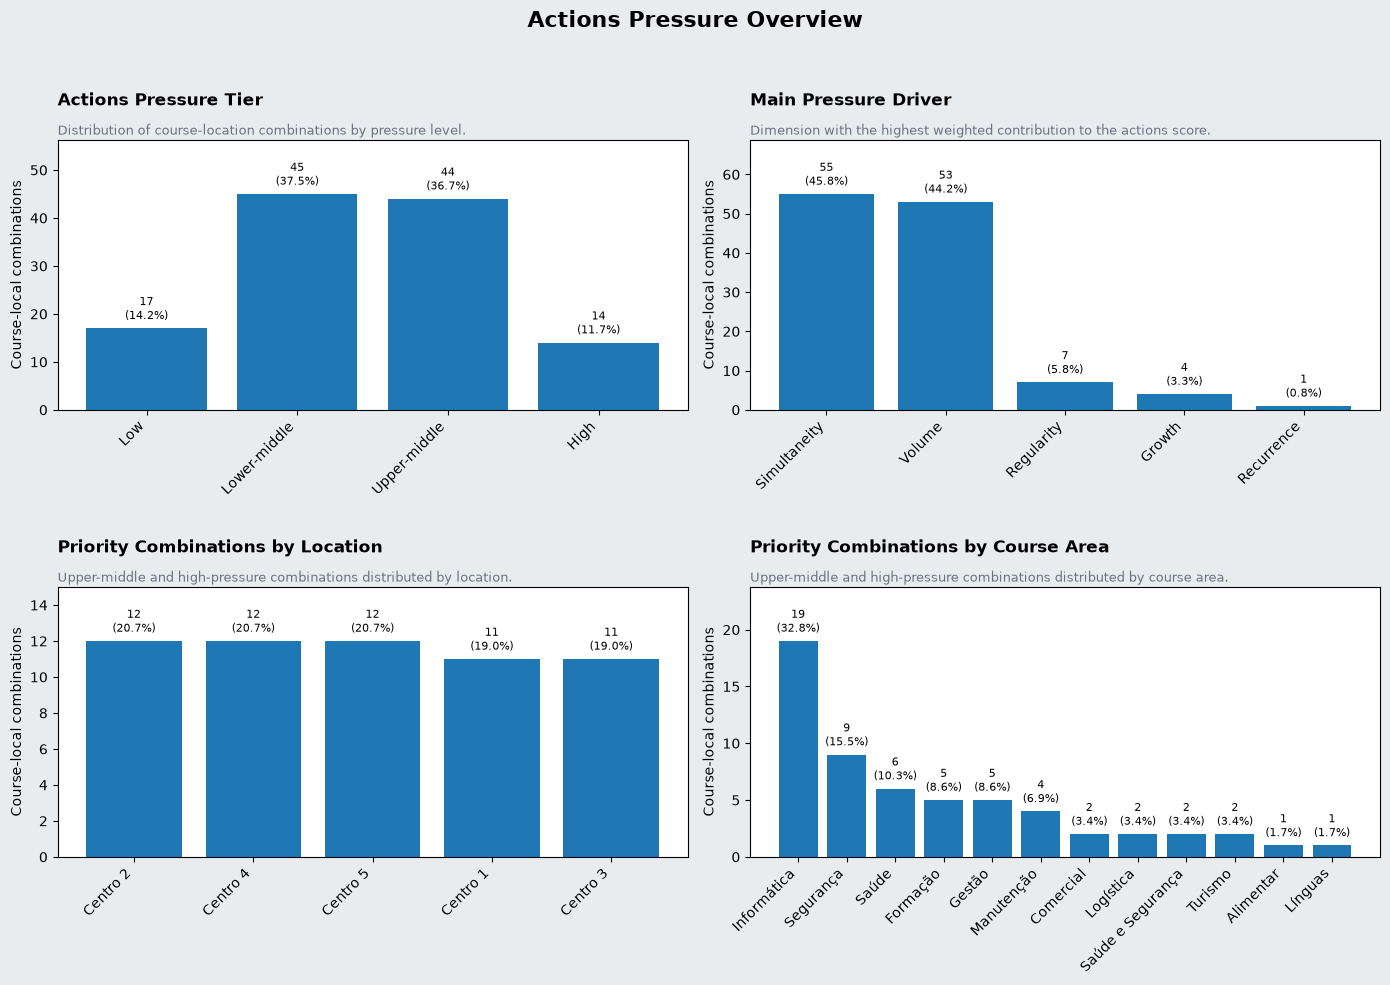

In [207]:
plot_actions_overview(
    charts=actions_score_overview_charts,
    title="Actions Pressure Overview",
    ylabel="Course-local combinations",
    nrows=2,
    ncols=2,
    figsize=(14, 10)
)

In [208]:
priority_actions_course_count_df = (
    priority_actions_df
    .groupby(
        [
            "course_id",
            "course_name"
        ],
        as_index=False
    )
    .agg(
        actions_count=(
            "local",
            "nunique"
        )
    )
    .assign(
        pct_actions=lambda df:
            df["actions_count"]
            .div(df["actions_count"].sum())
            .mul(100)
    )
    .sort_values(
        [
            "actions_count",
            "course_id"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


priority_actions_course_count_df

,course_id,course_name,actions_count,pct_actions
0,CYB,Cibersegurança Básica,5,8.620690
1,FOR,Formação Pedagógica Inicial de Formadores,5,8.620690
2,GER,Geriatria e Apoio ao Idoso,5,8.620690
3,PBI,Power BI e Visualização de Dados,5,8.620690
4,PYT,Introdução à Programação em Python,5,8.620690
5,SST,Saúde e Segurança no Trabalho,5,8.620690
6,EXC,Excel Aplicado à Gestão,4,6.896552
7,MNT,Manutenção Industrial Básica,4,6.896552
8,SEG,Segurança no Trabalho,3,5.172414
9,HOT,Housekeeping e Operações Hoteleiras,2,3.448276


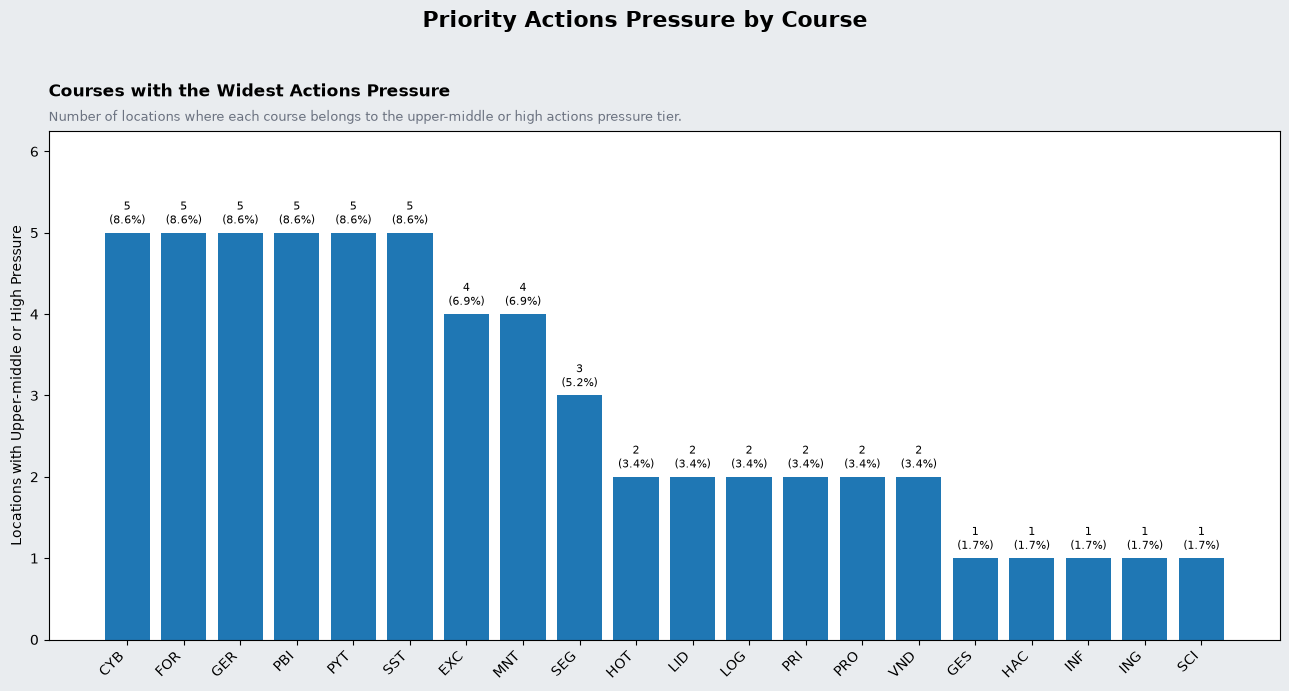

In [209]:
course_actions_pressure_charts = {
    "course_pressure": {
        "df": priority_actions_course_count_df,
        "label_column": "course_id",
        "title": "Courses with the Widest Actions Pressure",
        "description": (
            "Number of locations where each course belongs to "
            "the upper-middle or high actions pressure tier."
        )
    }
}

plot_actions_overview(
    charts=course_actions_pressure_charts,
    title="Priority Actions Pressure by Course",
    ylabel="Locations with Upper-middle or High Pressure",
    nrows=1,
    ncols=1,
    figsize=(13, 7)
)